In [52]:
from pathlib import Path

RESULTS_DIR = Path("Experiment_7_Results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [53]:
!pip -q install scikit-image

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_squared_error, mean_absolute_error
from skimage.metrics import structural_similarity as ssim

# Reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [54]:
# ============================================================
# LOAD MNIST
# ============================================================

(x_train_full, y_train_full), (x_test_full, y_test_full) = (
    keras.datasets.mnist.load_data()
)

# Laboratory subset
x_train = x_train_full[:10000]
y_train = y_train_full[:10000]

x_test = x_test_full[:2000]
y_test = y_test_full[:2000]

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training data:", x_train.shape)
print("Training labels:", y_train.shape)

print("Test data:", x_test.shape)
print("Test labels:", y_test.shape)

Training data: (10000, 28, 28, 1)
Training labels: (10000,)
Test data: (2000, 28, 28, 1)
Test labels: (2000,)


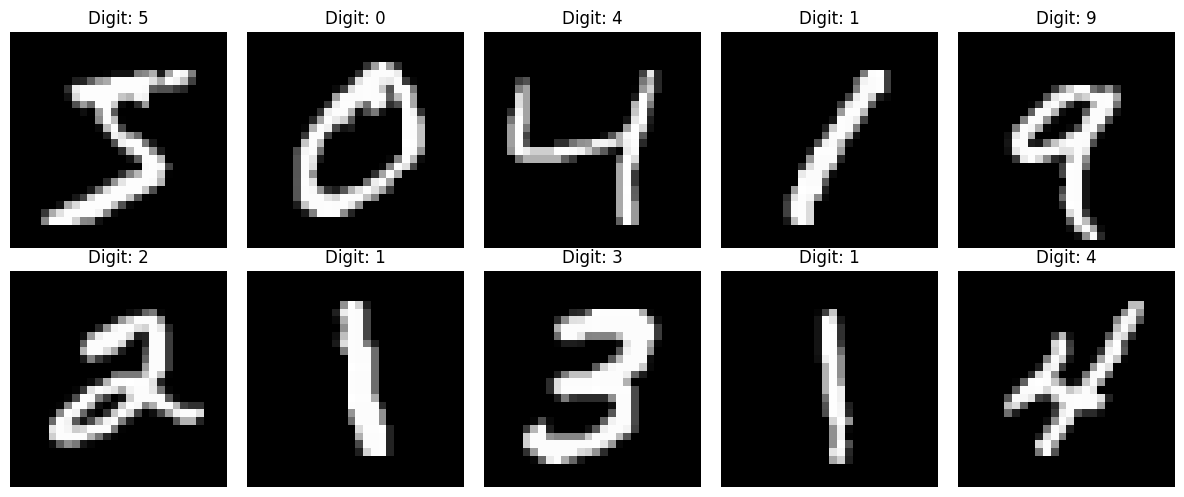

In [55]:
# ============================================================
# SAMPLE MNIST IMAGES
# ============================================================

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "Sample_mnist_images.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [56]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

VAL_SIZE = 1000

x_val = x_train[-VAL_SIZE:]
y_val = y_train[-VAL_SIZE:]

x_train_ae = x_train[:-VAL_SIZE]
y_train_ae = y_train[:-VAL_SIZE]

print("Train:", x_train_ae.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (9000, 28, 28, 1)
Validation: (1000, 28, 28, 1)
Test: (2000, 28, 28, 1)


In [57]:
# ============================================================
# RECONSTRUCTION METRICS
# ============================================================

def calculate_reconstruction_metrics(original, reconstructed):

    original_flat = original.reshape(original.shape[0], -1)
    reconstructed_flat = reconstructed.reshape(reconstructed.shape[0], -1)

    mse = np.mean(
        (original_flat - reconstructed_flat) ** 2
    )

    mae = np.mean(
        np.abs(original_flat - reconstructed_flat)
    )

    ssim_values = []

    for i in range(original.shape[0]):
        score = ssim(
            original[i].squeeze(),
            reconstructed[i].squeeze(),
            data_range=1.0
        )
        ssim_values.append(score)

    mean_ssim = np.mean(ssim_values)

    return mse, mae, mean_ssim

In [58]:
# ============================================================
# FULLY CONNECTED AUTOENCODER
# ============================================================

LATENT_DIM = 16

fc_autoencoder = keras.Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Flatten(),

    # Encoder
    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(LATENT_DIM, activation="relu"),

    # Decoder
    layers.Dense(32, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid"),

    layers.Reshape((28, 28, 1))

], name="Fully_Connected_Autoencoder")

fc_autoencoder.summary()

Model: "Fully_Connected_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_6 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,040 (824.38 KB)

 Trainable params: 211,040 (824.38 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# ============================================================
# TRAIN FC AUTOENCODER
# ============================================================

fc_autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

start_time = time.time()

history_fc = fc_autoencoder.fit(
    x_train_ae,
    x_train_ae,
    validation_data=(x_val, x_val),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

fc_training_time = time.time() - start_time

print(f"\nTraining time: {fc_training_time:.2f} seconds")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - loss: 0.3559 - val_loss: 0.2523
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2337 - val_loss: 0.2181
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1987 - val_loss: 0.1885
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1763 - val_loss: 0.1746
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1644 - val_loss: 0.1644
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1548 - val_loss: 0.1575
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1493 - val_loss: 0.1532
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1455 - val_loss: 0.1499
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1425 - val_loss: 0.1472
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1400 - val_loss: 0.1458
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1378 - val_loss: 0.1429
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1358 

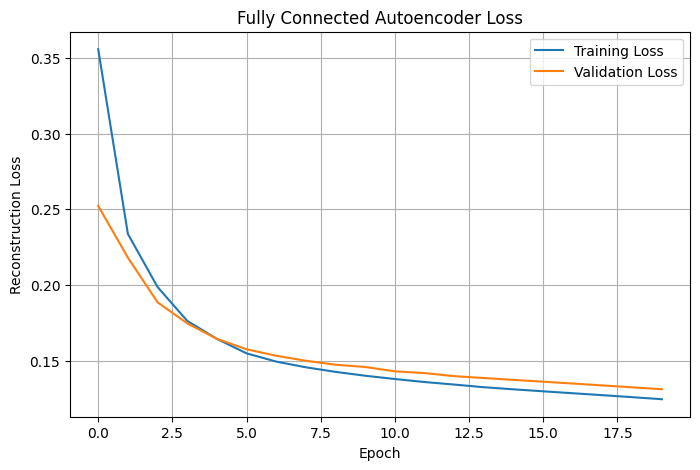

In [60]:
# ============================================================
# PLOT 2 — FC-AE TRAINING / VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_fc.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fc.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Fully Connected Autoencoder Loss")

plt.legend()
plt.grid(True)
plt.savefig(
    RESULTS_DIR / "Fully_Connected_Autoencoder_Loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [61]:
# ============================================================
# FC-AE RECONSTRUCTION
# ============================================================

fc_reconstructed = fc_autoencoder.predict(
    x_test,
    batch_size=128
)

print("Reconstructed shape:", fc_reconstructed.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Reconstructed shape: (2000, 28, 28, 1)


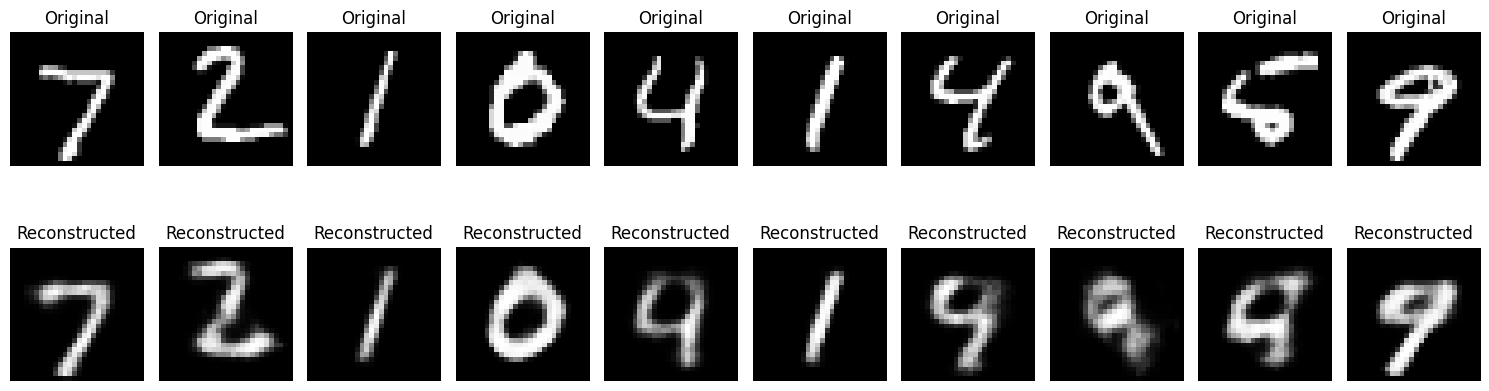

In [62]:
# ============================================================
# PLOT 1 — ORIGINAL VS RECONSTRUCTION
# ============================================================

plt.figure(figsize=(15, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 10, i + 11)
    plt.imshow(fc_reconstructed[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "Original_vs_Reconstructed.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [63]:
# ============================================================
# FC-AE METRICS
# ============================================================

fc_mse, fc_mae, fc_ssim = calculate_reconstruction_metrics(
    x_test,
    fc_reconstructed
)

fc_params = fc_autoencoder.count_params()

print("Fully Connected Autoencoder")
print("--------------------------------")
print(f"MSE       : {fc_mse:.6f}")
print(f"MAE       : {fc_mae:.6f}")
print(f"SSIM      : {fc_ssim:.6f}")
print(f"Parameters: {fc_params:,}")
print(f"Time      : {fc_training_time:.2f} sec")

Fully Connected Autoencoder
--------------------------------
MSE       : 0.022371
MAE       : 0.059099
SSIM      : 0.732669
Parameters: 211,040
Time      : 22.24 sec


In [64]:
# ============================================================
# CONVOLUTIONAL AUTOENCODER
# ============================================================

cae = keras.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        2,
        padding="same"
    ),

    layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        2,
        padding="same"
    ),

    layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    ),

    # Decoder
    layers.UpSampling2D(2),

    layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D(2),

    layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )

], name="Convolutional_Autoencoder")

cae.summary()

Model: "Convolutional_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# ============================================================
# TRAIN CAE
# ============================================================

cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

start_time = time.time()

history_cae = cae.fit(
    x_train_ae,
    x_train_ae,
    validation_data=(x_val, x_val),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

cae_training_time = time.time() - start_time

print(f"\nCAE training time: {cae_training_time:.2f} seconds")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.2619 - val_loss: 0.1141
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0962 - val_loss: 0.0904
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0851 - val_loss: 0.0843
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0804 - val_loss: 0.0807
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0774 - val_loss: 0.0776
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0754 - val_loss: 0.0761
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0740 - val_loss: 0.0760
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0731 - val_loss: 0.0744
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0723 - val_loss: 0.0733
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0717 - val_loss: 0.0727
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0712 - val_loss: 0.0722
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0707 - val_

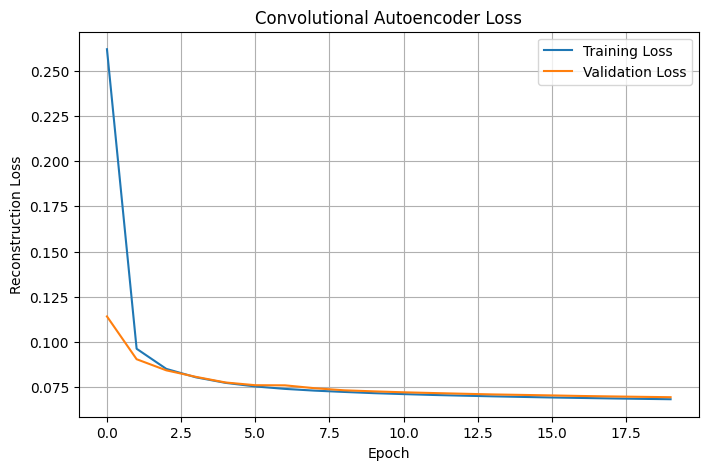

In [66]:
# ============================================================
# CAE LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_cae.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cae.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Convolutional Autoencoder Loss")

plt.legend()
plt.grid(True)
plt.savefig(
    RESULTS_DIR / "Convolutional_Autoencoder_Loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [67]:
# ============================================================
# CAE RECONSTRUCTION
# ============================================================

cae_reconstructed = cae.predict(
    x_test,
    batch_size=128
)

cae_mse, cae_mae, cae_ssim = calculate_reconstruction_metrics(
    x_test,
    cae_reconstructed
)

cae_params = cae.count_params()

print("Convolutional Autoencoder")
print("--------------------------------")
print(f"MSE       : {cae_mse:.6f}")
print(f"MAE       : {cae_mae:.6f}")
print(f"SSIM      : {cae_ssim:.6f}")
print(f"Parameters: {cae_params:,}")
print(f"Time      : {cae_training_time:.2f} sec")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Convolutional Autoencoder
--------------------------------
MSE       : 0.002581
MAE       : 0.015000
SSIM      : 0.973997
Parameters: 74,497
Time      : 18.24 sec


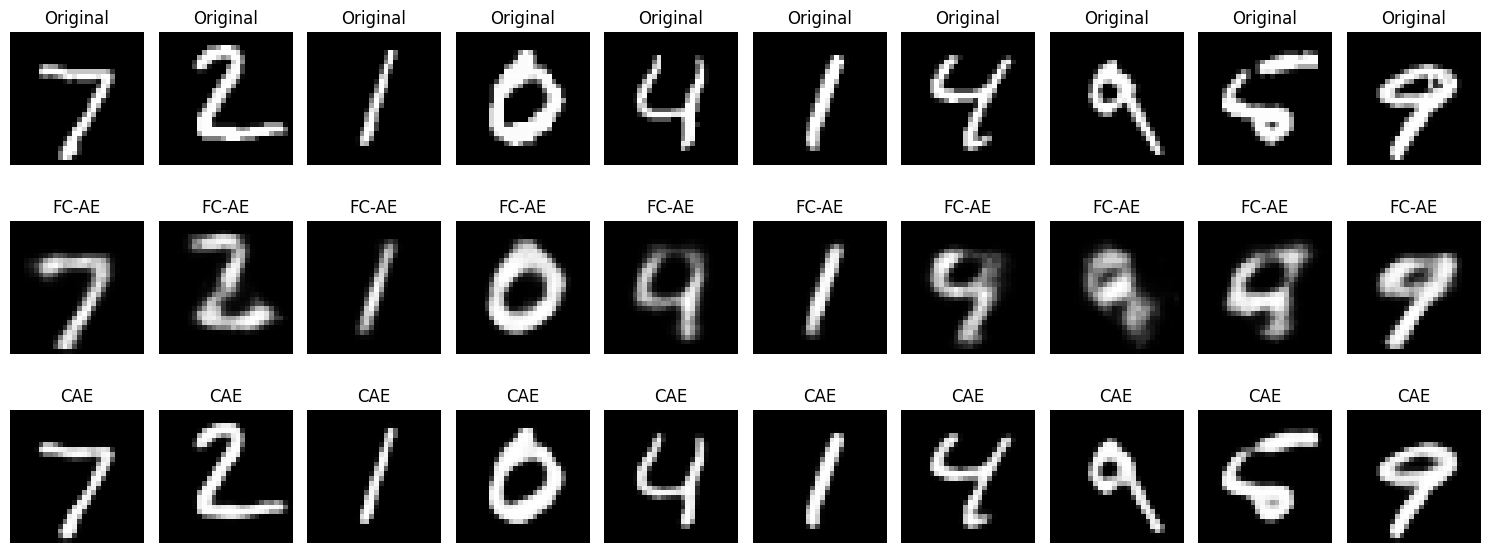

In [68]:
# ============================================================
# PLOT 3 — FC-AE VS CAE
# ============================================================

plt.figure(figsize=(15, 6))

for i in range(10):

    # Original
    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # FC-AE
    plt.subplot(3, 10, i + 11)
    plt.imshow(fc_reconstructed[i].squeeze(), cmap="gray")
    plt.title("FC-AE")
    plt.axis("off")

    # CAE
    plt.subplot(3, 10, i + 21)
    plt.imshow(cae_reconstructed[i].squeeze(), cmap="gray")
    plt.title("CAE")
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "FC_AE_vs_CAE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [69]:
# ============================================================
# FC-AE VS CAE TABLE
# ============================================================

comparison_basic = pd.DataFrame({
    "Model": [
        "Fully Connected AE",
        "Convolutional AE"
    ],

    "MSE": [
        fc_mse,
        cae_mse
    ],

    "MAE": [
        fc_mae,
        cae_mae
    ],

    "SSIM": [
        fc_ssim,
        cae_ssim
    ],

    "Parameters": [
        fc_params,
        cae_params
    ],

    "Time (sec)": [
        fc_training_time,
        cae_training_time
    ]
})

comparison_basic

,Model,MSE,MAE,SSIM,Parameters,Time (sec)
0,Fully Connected AE,0.022371,0.059099,0.732669,211040,22.238239
1,Convolutional AE,0.002581,0.015000,0.973997,74497,18.235996


In [70]:
# ============================================================
# NOISE FUNCTIONS
# ============================================================

def add_gaussian_noise(images, sigma):

    noise = np.random.normal(
        loc=0.0,
        scale=sigma,
        size=images.shape
    )

    noisy = images + noise

    return np.clip(noisy, 0.0, 1.0).astype(np.float32)


def add_salt_pepper_noise(images, probability):

    noisy = images.copy()

    random_values = np.random.random(images.shape)

    salt = random_values < (probability / 2)
    pepper = (
        (random_values >= probability / 2)
        & (random_values < probability)
    )

    noisy[salt] = 1.0
    noisy[pepper] = 0.0

    return noisy.astype(np.float32)

In [71]:
# ============================================================
# DENOISING TRAINING DATA
# ============================================================

NOISE_SIGMA = 0.2

x_train_noisy = add_gaussian_noise(
    x_train_ae,
    NOISE_SIGMA
)

x_val_noisy = add_gaussian_noise(
    x_val,
    NOISE_SIGMA
)

print("Clean:", x_train_ae.shape)
print("Noisy:", x_train_noisy.shape)

Clean: (9000, 28, 28, 1)
Noisy: (9000, 28, 28, 1)


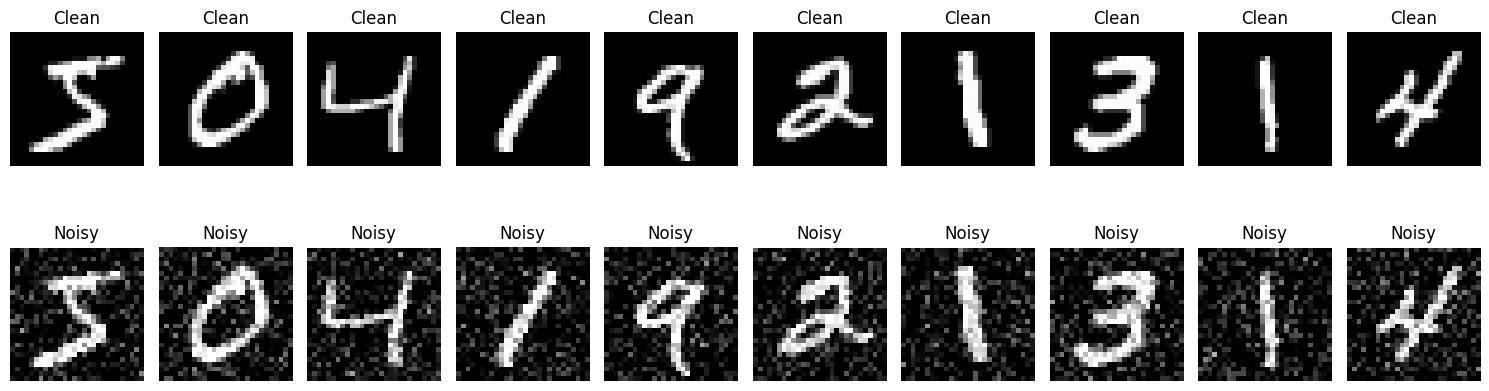

In [72]:
# ============================================================
# CLEAN VS NOISY
# ============================================================

plt.figure(figsize=(15, 5))

for i in range(10):

    plt.subplot(2, 10, i + 1)
    plt.imshow(x_train_ae[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "Clean_vs_Noisy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [73]:
# ============================================================
# DENOISING CONVOLUTIONAL AUTOENCODER
# ============================================================

denoising_cae = keras.Sequential([

    layers.Input(shape=(28, 28, 1)),

    # Encoder
    layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        2,
        padding="same"
    ),

    layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(
        2,
        padding="same"
    ),

    layers.Conv2D(
        64,
        3,
        activation="relu",
        padding="same"
    ),

    # Decoder
    layers.UpSampling2D(2),

    layers.Conv2D(
        32,
        3,
        activation="relu",
        padding="same"
    ),

    layers.UpSampling2D(2),

    layers.Conv2D(
        1,
        3,
        activation="sigmoid",
        padding="same"
    )

], name="Denoising_CAE")

denoising_cae.summary()

Model: "Denoising_CAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# ============================================================
# TRAIN DENOISING CAE
# ============================================================

denoising_cae.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

start_time = time.time()

history_dae = denoising_cae.fit(
    x_train_noisy,
    x_train_ae,
    validation_data=(x_val_noisy, x_val),
    epochs=20,
    batch_size=128,
    shuffle=True,
    verbose=1
)

dae_training_time = time.time() - start_time

print(f"\nDenoising CAE training time: {dae_training_time:.2f} seconds")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.2644 - val_loss: 0.1284
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1104 - val_loss: 0.1024
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0966 - val_loss: 0.0945
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0904 - val_loss: 0.0901
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0871 - val_loss: 0.0874
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0848 - val_loss: 0.0858
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0830 - val_loss: 0.0840
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0818 - val_loss: 0.0828
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0809 - val_loss: 0.0821
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0801 - val_loss: 0.0815
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0794 - val_loss: 0.0810
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0789 - val

In [75]:
# ============================================================
# DENOISING TEST IMAGES
# ============================================================

x_test_noisy = add_gaussian_noise(
    x_test,
    NOISE_SIGMA
)

dae_reconstructed = denoising_cae.predict(
    x_test_noisy,
    batch_size=128
)

print("Denoised shape:", dae_reconstructed.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Denoised shape: (2000, 28, 28, 1)


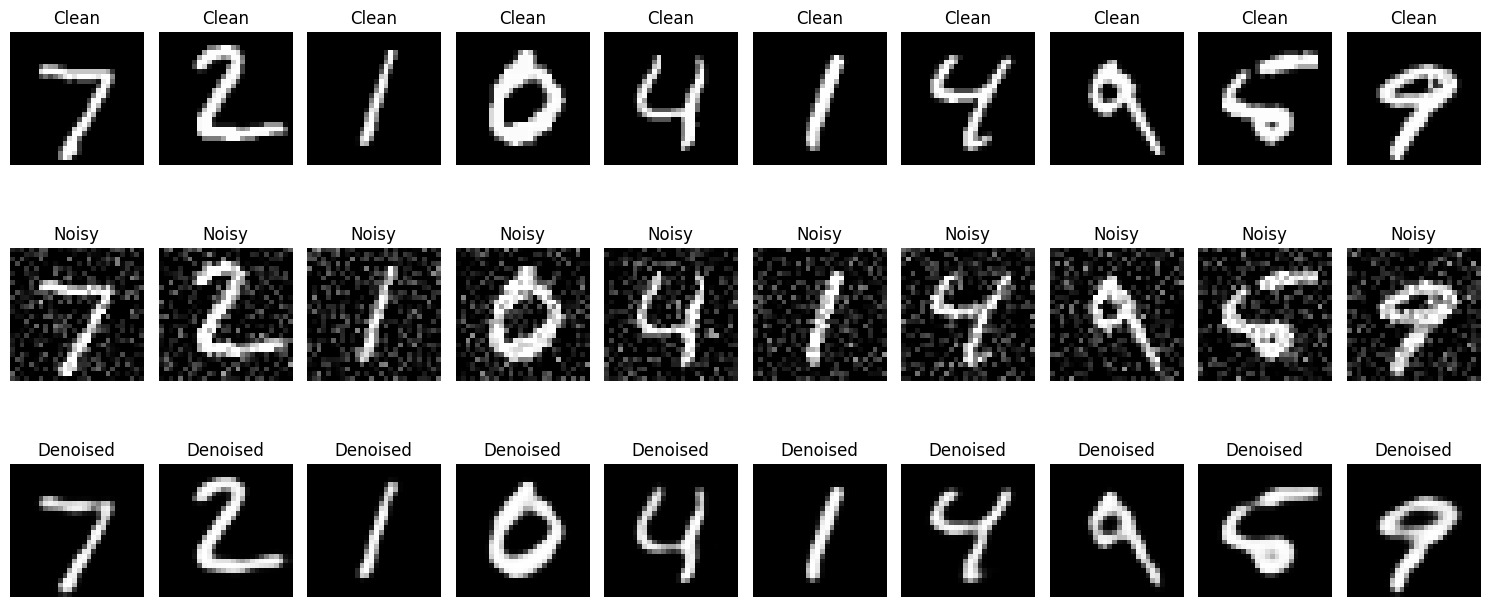

In [76]:
# ============================================================
# PLOT 4 — CLEAN VS NOISY VS DENOISED
# ============================================================

plt.figure(figsize=(15, 7))

for i in range(10):

    plt.subplot(3, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    plt.subplot(3, 10, i + 11)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, 10, i + 21)
    plt.imshow(dae_reconstructed[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "Clean_vs_Noisy_vs_Denoised.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [77]:
# ============================================================
# GAUSSIAN NOISE LEVEL STUDY
# ============================================================

gaussian_levels = [0.1, 0.2, 0.3]

gaussian_results = []

for sigma in gaussian_levels:

    noisy_test = add_gaussian_noise(
        x_test,
        sigma
    )

    denoised = denoising_cae.predict(
        noisy_test,
        batch_size=128,
        verbose=0
    )

    mse, mae, ssim_value = calculate_reconstruction_metrics(
        x_test,
        denoised
    )

    gaussian_results.append({
        "Noise Level": sigma,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value
    })

gaussian_results = pd.DataFrame(
    gaussian_results
)

gaussian_results

,Noise Level,MSE,MAE,SSIM
0,0.1,0.003880,0.018540,0.954337
1,0.2,0.005033,0.022156,0.940561
2,0.3,0.007575,0.029765,0.879907


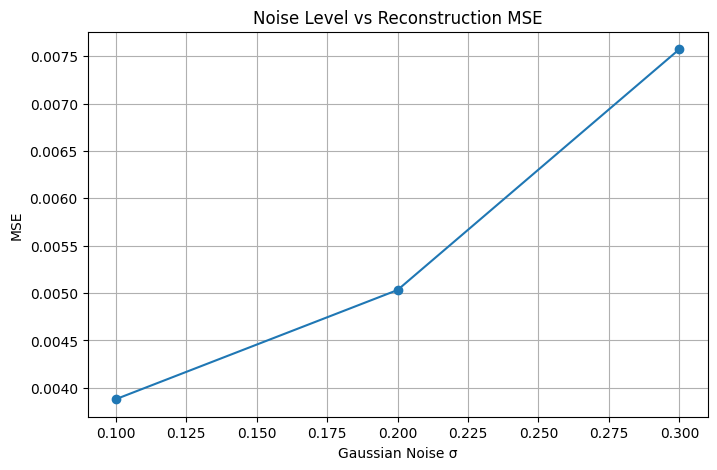

In [78]:
# ============================================================
# PLOT 5A — NOISE LEVEL VS MSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    gaussian_results["Noise Level"],
    gaussian_results["MSE"],
    marker="o"
)

plt.xlabel("Gaussian Noise σ")
plt.ylabel("MSE")
plt.title("Noise Level vs Reconstruction MSE")
plt.grid(True)
plt.savefig(
    RESULTS_DIR / "Noise_Level_vs_MSE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

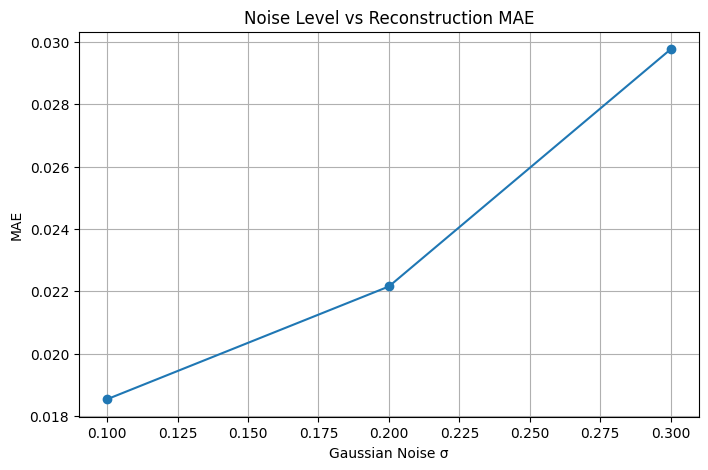

In [79]:
# ============================================================
# PLOT 5B — NOISE LEVEL VS MAE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    gaussian_results["Noise Level"],
    gaussian_results["MAE"],
    marker="o"
)

plt.xlabel("Gaussian Noise σ")
plt.ylabel("MAE")
plt.title("Noise Level vs Reconstruction MAE")
plt.grid(True)
plt.savefig(
    RESULTS_DIR / "Noise_Level_vs_MAE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

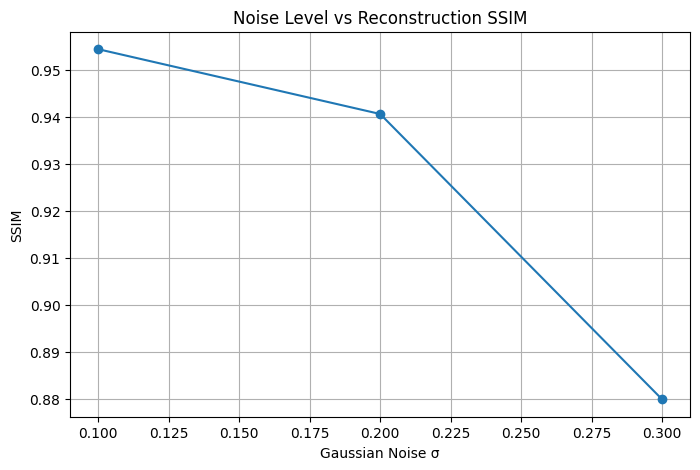

In [80]:
# ============================================================
# PLOT 5C — NOISE LEVEL VS SSIM
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    gaussian_results["Noise Level"],
    gaussian_results["SSIM"],
    marker="o"
)

plt.xlabel("Gaussian Noise σ")
plt.ylabel("SSIM")
plt.title("Noise Level vs Reconstruction SSIM")
plt.grid(True)

plt.savefig(
    RESULTS_DIR / "Noise_Level_vs_SSIM.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [81]:
# ============================================================
# SALT-AND-PEPPER NOISE STUDY
# ============================================================

sp_levels = [0.05, 0.10, 0.20]

sp_results = []

for p in sp_levels:

    noisy_test = add_salt_pepper_noise(
        x_test,
        p
    )

    denoised = denoising_cae.predict(
        noisy_test,
        batch_size=128,
        verbose=0
    )

    mse, mae, ssim_value = calculate_reconstruction_metrics(
        x_test,
        denoised
    )

    sp_results.append({
        "Noise Level": p,
        "MSE": mse,
        "MAE": mae,
        "SSIM": ssim_value
    })

sp_results = pd.DataFrame(sp_results)

sp_results

,Noise Level,MSE,MAE,SSIM
0,0.05,0.005430,0.022501,0.928546
1,0.10,0.007945,0.028724,0.880935
2,0.20,0.014955,0.044090,0.752346


In [82]:
# ============================================================
# VAE ENCODER
# ============================================================

VAE_LATENT_DIM = 2

encoder_inputs = keras.Input(
    shape=(28, 28, 1),
    name="encoder_input"
)

x = layers.Conv2D(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(encoder_inputs)

x = layers.Conv2D(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Flatten()(x)

x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(
    VAE_LATENT_DIM,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    VAE_LATENT_DIM,
    name="z_log_var"
)(x)

In [83]:
# ============================================================
# REPARAMETERIZATION
# ============================================================

class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        z = (
            z_mean
            + tf.exp(0.5 * z_log_var)
            * epsilon
        )

        return z


z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="VAE_Encoder"
)

encoder.summary()

Model: "VAE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 14, 14,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 3136)      │          0 │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 128)       │    401,536 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_38[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 420,868 (1.61 MB)

 Trainable params: 420,868 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# ============================================================
# VAE DECODER
# ============================================================

latent_inputs = keras.Input(
    shape=(VAE_LATENT_DIM,),
    name="z_sampling"
)

x = layers.Dense(
    7 * 7 * 64,
    activation="relu"
)(latent_inputs)

x = layers.Reshape(
    (7, 7, 64)
)(x)

x = layers.Conv2DTranspose(
    64,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

x = layers.Conv2DTranspose(
    32,
    3,
    strides=2,
    padding="same",
    activation="relu"
)(x)

decoder_outputs = layers.Conv2DTranspose(
    1,
    3,
    padding="same",
    activation="sigmoid"
)(x)

decoder = keras.Model(
    latent_inputs,
    decoder_outputs,
    name="VAE_Decoder"
)

decoder.summary()

Model: "VAE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
# ============================================================
# VAE MODEL
# ============================================================

class VAE(keras.Model):

    def __init__(self, encoder, decoder, **kwargs):

        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(
            name="loss"
        )

        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )

        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):

        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            z_mean, z_log_var, z = self.encoder(
                data,
                training=True
            )

            reconstruction = self.decoder(
                z,
                training=True
            )

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )

            # KL divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1
                    + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = (
                reconstruction_loss
                + kl_loss
            )

        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(
                gradients,
                self.trainable_weights
            )
        )

        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result()
        }

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        z_mean, z_log_var, z = self.encoder(
            data,
            training=False
        )

        reconstruction = self.decoder(
            z,
            training=False
        )

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                keras.losses.binary_crossentropy(
                    data,
                    reconstruction
                ),
                axis=(1, 2)
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }

    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        return self.decoder(z)

In [86]:
# ============================================================
# TRAIN VAE
# ============================================================

vae = VAE(
    encoder,
    decoder
)

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    )
)

start_time = time.time()

history_vae = vae.fit(
    x_train_ae,
    epochs=20,
    batch_size=128,
    validation_data=(x_val, None),
    shuffle=True,
    verbose=1
)

vae_training_time = time.time() - start_time

print(
    f"\nVAE training time: "
    f"{vae_training_time:.2f} seconds"
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - kl_loss: 2.4600 - loss: 301.6085 - reconstruction_loss: 299.1486 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 2.1618 - loss: 201.7448 - reconstruction_loss: 199.5830 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 2.3577 - loss: 193.8608 - reconstruction_loss: 191.5031 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.4343 - loss: 185.4120 - reconstruction_loss: 181.9777 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - kl_loss: 3.9262 - loss: 179.7292 - reconstruction_loss: 175.8029 - val_kl_loss: 0.0000e+00 - val_loss: 0.0000e+00 - val_reconstruc

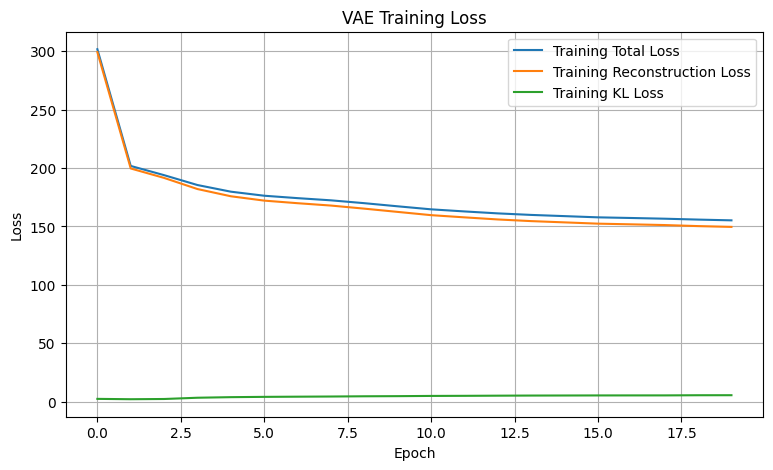

In [87]:
# ============================================================
# PLOT 9 — VAE LOSS
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    history_vae.history["loss"],
    label="Training Total Loss"
)

plt.plot(
    history_vae.history["reconstruction_loss"],
    label="Training Reconstruction Loss"
)

plt.plot(
    history_vae.history["kl_loss"],
    label="Training KL Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")

plt.legend()
plt.grid(True)

plt.savefig(
    RESULTS_DIR / "VAE_Training_Loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [88]:
# ============================================================
# VAE RECONSTRUCTION
# ============================================================

z_mean_test, z_log_var_test, z_test = encoder.predict(
    x_test,
    batch_size=128
)

vae_reconstructed = decoder.predict(
    z_test,
    batch_size=128
)

print("VAE reconstruction:", vae_reconstructed.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
VAE reconstruction: (2000, 28, 28, 1)


In [89]:
# ============================================================
# VAE RECONSTRUCTION METRICS
# ============================================================

vae_mse, vae_mae, vae_ssim = calculate_reconstruction_metrics(
    x_test,
    vae_reconstructed
)

print("VAE Reconstruction")
print("--------------------------------")
print(f"MSE  : {vae_mse:.6f}")
print(f"MAE  : {vae_mae:.6f}")
print(f"SSIM : {vae_ssim:.6f}")

VAE Reconstruction
--------------------------------
MSE  : 0.046071
MAE  : 0.105932
SSIM : 0.477930


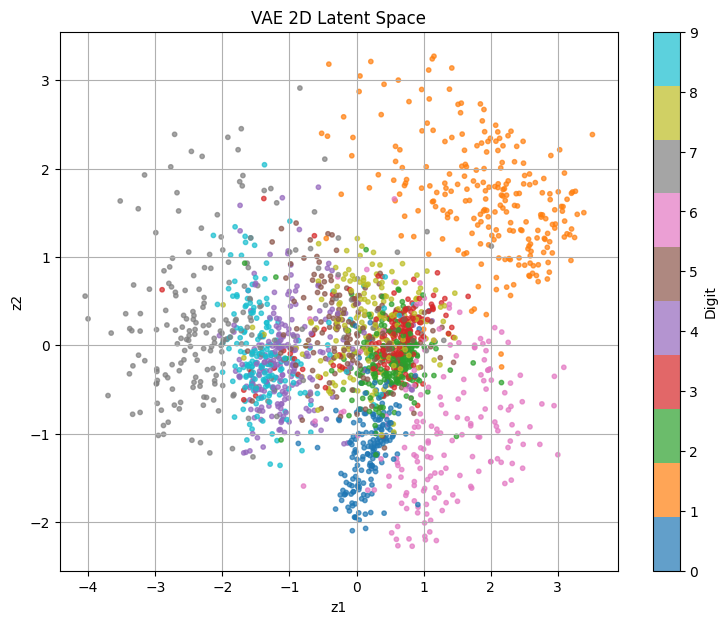

In [90]:
# ============================================================
# PLOT 6 — VAE LATENT SPACE
# ============================================================

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    z_mean_test[:, 0],
    z_mean_test[:, 1],
    c=y_test,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE 2D Latent Space")

plt.colorbar(
    scatter,
    label="Digit"
)

plt.grid(True)

plt.savefig(
    RESULTS_DIR / "VAE_Latent_Space.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

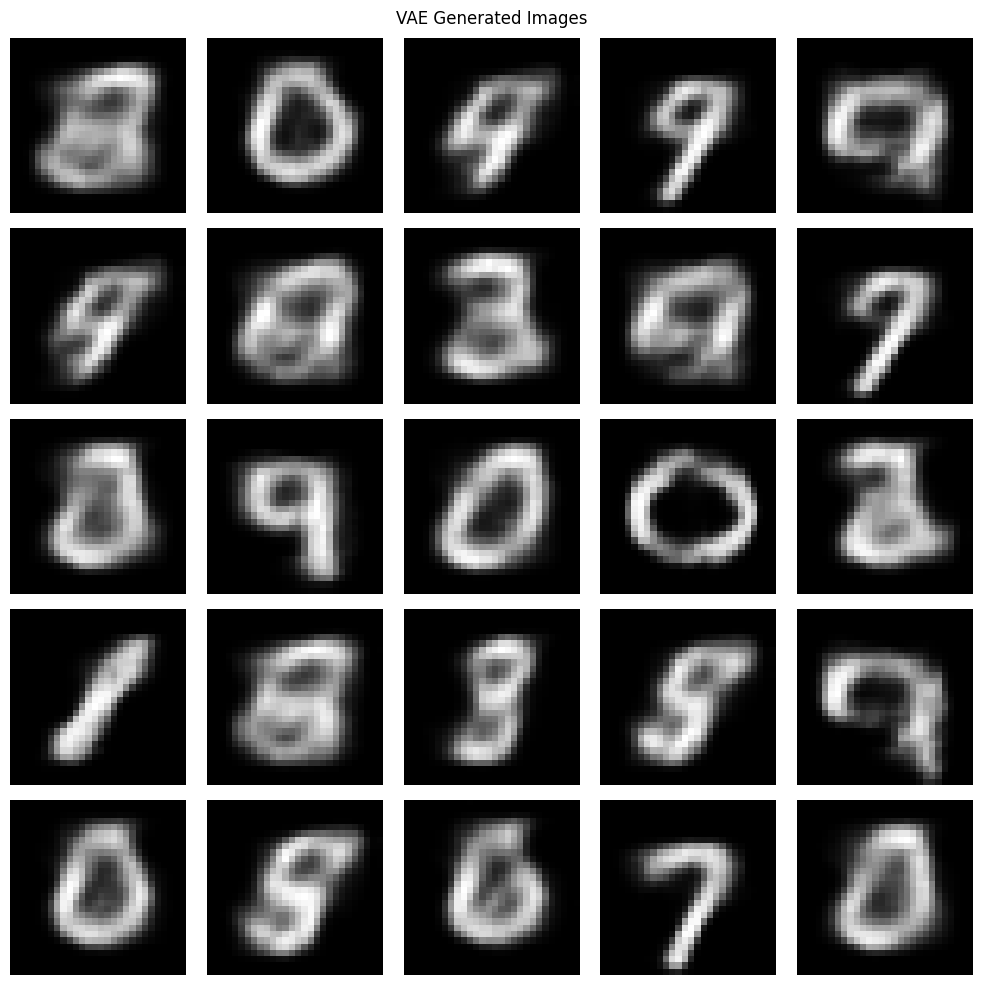

In [91]:
# ============================================================
# PLOT 7 — RANDOM VAE GENERATION
# ============================================================

NUM_GENERATED = 25

random_latent = np.random.normal(
    size=(NUM_GENERATED, VAE_LATENT_DIM)
)

generated_images = decoder.predict(
    random_latent,
    verbose=0
)

plt.figure(figsize=(10, 10))

for i in range(NUM_GENERATED):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        generated_images[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle("VAE Generated Images")
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "VAE_Generated_Images.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

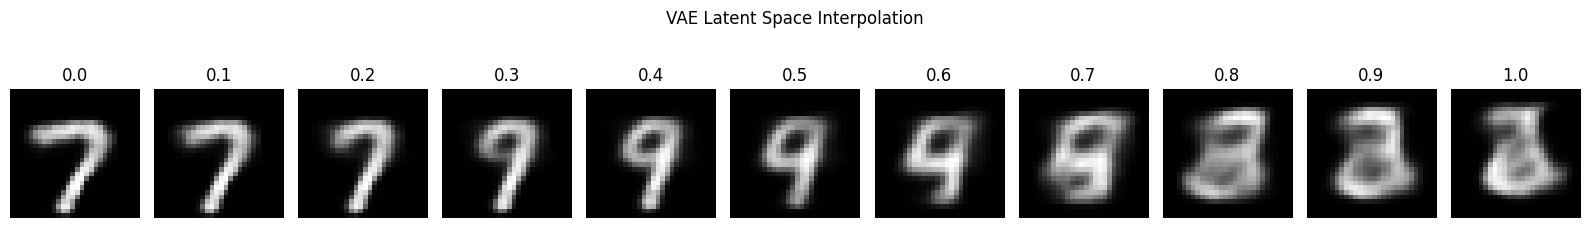

In [92]:
# ============================================================
# PLOT 8 — LATENT SPACE INTERPOLATION
# ============================================================

z_a = z_mean_test[0]
z_b = z_mean_test[1]

alphas = np.linspace(
    0,
    1,
    11
)

interpolated_latents = np.array([
    (1 - alpha) * z_a + alpha * z_b
    for alpha in alphas
])

interpolated_images = decoder.predict(
    interpolated_latents,
    verbose=0
)

plt.figure(figsize=(16, 3))

for i in range(len(alphas)):

    plt.subplot(1, 11, i + 1)

    plt.imshow(
        interpolated_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(f"{alphas[i]:.1f}")
    plt.axis("off")

plt.tight_layout()
plt.suptitle("VAE Latent Space Interpolation")

plt.savefig(
    RESULTS_DIR / "VAE_Latent_Space_Interpolation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

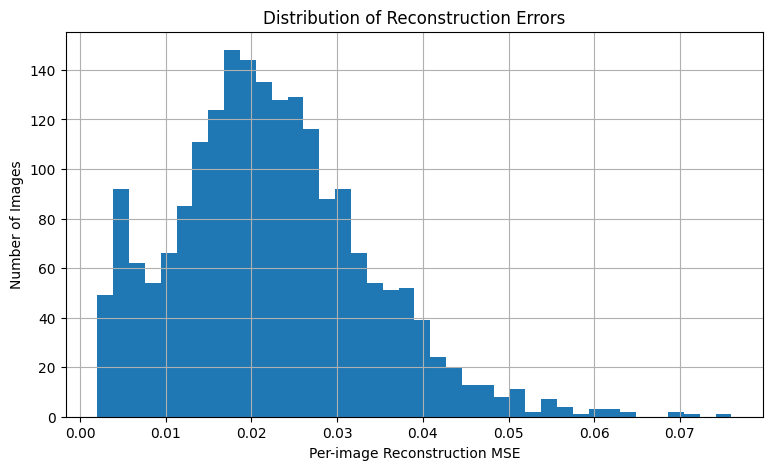

Mean error: 0.022371154
Maximum error: 0.07601914


In [93]:
# ============================================================
# PLOT 9 — RECONSTRUCTION ERROR DISTRIBUTION
# ============================================================

reconstruction_errors = np.mean(
    (
        x_test - fc_reconstructed
    ) ** 2,
    axis=(1, 2, 3)
)

plt.figure(figsize=(9, 5))

plt.hist(
    reconstruction_errors,
    bins=40
)

plt.xlabel("Per-image Reconstruction MSE")
plt.ylabel("Number of Images")
plt.title("Distribution of Reconstruction Errors")

plt.grid(True)

plt.savefig(
    RESULTS_DIR / "Reconstruction_Error_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(
    "Mean error:",
    reconstruction_errors.mean()
)

print(
    "Maximum error:",
    reconstruction_errors.max()
)

In [94]:
# ============================================================
# HIGH-ERROR IMAGE ANALYSIS
# ============================================================

top5_indices = np.argsort(
    reconstruction_errors
)[-5:][::-1]

print("Highest-error indices:")
print(top5_indices)

print("\nErrors:")

for idx in top5_indices:
    print(
        f"Index {idx}: "
        f"{reconstruction_errors[idx]:.6f}"
    )

Highest-error indices:
[1782   54  654  338    8]

Errors:
Index 1782: 0.076019
Index 54: 0.070914
Index 654: 0.069982
Index 338: 0.069082
Index 8: 0.064537


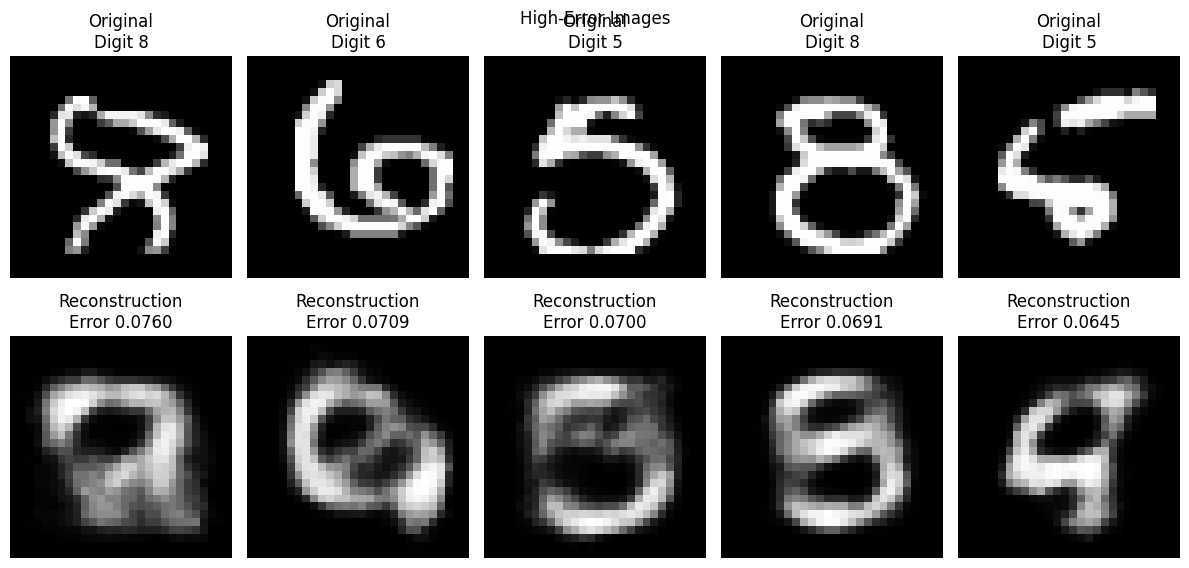

In [95]:
# ============================================================
# DISPLAY HIGH-ERROR IMAGES
# ============================================================

plt.figure(figsize=(12, 6))

for position, idx in enumerate(top5_indices):

    # Original
    plt.subplot(2, 5, position + 1)

    plt.imshow(
        x_test[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Original\nDigit {y_test[idx]}"
    )

    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 5, position + 6)

    plt.imshow(
        fc_reconstructed[idx].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Reconstruction\nError {reconstruction_errors[idx]:.4f}"
    )

    plt.axis("off")

plt.tight_layout()
plt.suptitle("High-Error Images")

plt.savefig(
    RESULTS_DIR / "High_Error_Images.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [96]:
# ============================================================
# CONSOLIDATED RESULTS
# ============================================================

# Calculate Denoising CAE metrics
dae_mse, dae_mae, dae_ssim = calculate_reconstruction_metrics(
    x_test,
    dae_reconstructed
)

# VAE parameter count
# The custom VAE wrapper itself is not explicitly built,
# so count parameters from its encoder and decoder.
vae_params = (
    encoder.count_params()
    + decoder.count_params()
)

# Create consolidated results table
results = pd.DataFrame({

    "Model": [
        "FC Autoencoder",
        "Convolutional Autoencoder",
        "Denoising CAE",
        "VAE"
    ],

    "MSE": [
        fc_mse,
        cae_mse,
        dae_mse,
        vae_mse
    ],

    "MAE": [
        fc_mae,
        cae_mae,
        dae_mae,
        vae_mae
    ],

    "SSIM": [
        fc_ssim,
        cae_ssim,
        dae_ssim,
        vae_ssim
    ],

    "Parameters": [
        fc_params,
        cae_params,
        denoising_cae.count_params(),
        vae_params
    ],

    "Time (sec)": [
        fc_training_time,
        cae_training_time,
        dae_training_time,
        vae_training_time
    ]
})

results

,Model,MSE,MAE,SSIM,Parameters,Time (sec)
0,FC Autoencoder,0.022371,0.059099,0.732669,211040,22.238239
1,Convolutional Autoencoder,0.002581,0.015000,0.973997,74497,18.235996
2,Denoising CAE,0.004983,0.022065,0.941305,74497,17.704153
3,VAE,0.046071,0.105932,0.477930,485957,21.735466


In [97]:
# ============================================================
# VAE LOSS COMPONENTS
# ============================================================

vae_test_results = vae.evaluate(
    x_test,
    verbose=0,
    return_dict=True
)

print("VAE Test Losses")
print("-----------------------------")

for key, value in vae_test_results.items():
    print(f"{key}: {value:.6f}")

VAE Test Losses
-----------------------------
kl_loss: 0.000000
loss: 0.000000
reconstruction_loss: 0.000000


In [98]:
# ============================================================
# LATENT DIMENSION STUDY
# ============================================================

def build_fc_autoencoder(latent_dim):

    model = keras.Sequential([

        layers.Input(shape=(28, 28, 1)),

        layers.Flatten(),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(
            latent_dim,
            activation="relu"
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(
            128,
            activation="relu"
        ),

        layers.Dense(
            784,
            activation="sigmoid"
        ),

        layers.Reshape((28, 28, 1))

    ])

    return model

In [99]:
# ============================================================
# TRAIN DIFFERENT LATENT DIMENSIONS
# ============================================================

latent_dimensions = [2, 8, 16, 32]

latent_results = []

for latent_dim in latent_dimensions:

    print(
        f"\nTraining latent dimension = {latent_dim}"
    )

    model = build_fc_autoencoder(
        latent_dim
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="binary_crossentropy"
    )

    start = time.time()

    model.fit(
        x_train_ae,
        x_train_ae,
        validation_data=(x_val, x_val),
        epochs=20,
        batch_size=128,
        verbose=0
    )

    training_time = time.time() - start

    reconstructed = model.predict(
        x_test,
        batch_size=128,
        verbose=0
    )

    mse, mae, ssim_value = (
        calculate_reconstruction_metrics(
            x_test,
            reconstructed
        )
    )

    latent_results.append({

        "Latent Dimension": latent_dim,

        "MSE": mse,

        "SSIM": ssim_value,

        "Parameters": model.count_params(),

        "Time (sec)": training_time

    })

latent_results = pd.DataFrame(
    latent_results
)

latent_results


Training latent dimension = 2

Training latent dimension = 8

Training latent dimension = 16

Training latent dimension = 32


,Latent Dimension,MSE,SSIM,Parameters,Time (sec)
0,2,0.047406,0.438639,210130,10.513563
1,8,0.030621,0.643718,210520,10.865759
2,16,0.022812,0.727550,211040,10.268541
3,32,0.021482,0.743899,212080,10.271597


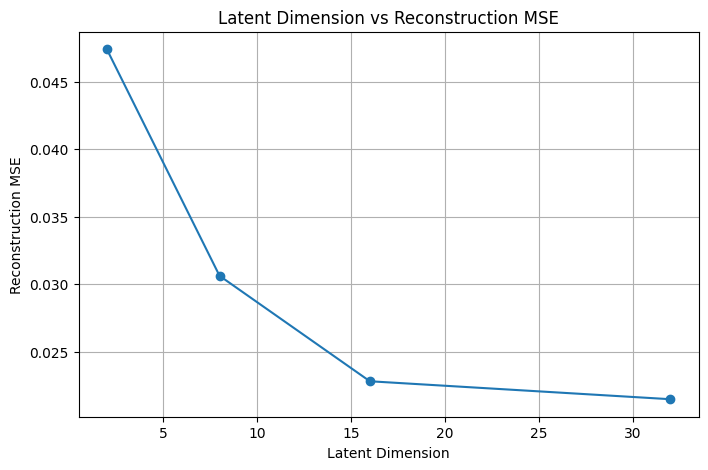

In [100]:
# ============================================================
# PLOT 10 — LATENT DIMENSION VS MSE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    latent_results["Latent Dimension"],
    latent_results["MSE"],
    marker="o"
)

plt.xlabel("Latent Dimension")
plt.ylabel("Reconstruction MSE")
plt.title("Latent Dimension vs Reconstruction MSE")

plt.grid(True)

plt.savefig(
    RESULTS_DIR / "Latent_Dimension_vs_MSE.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

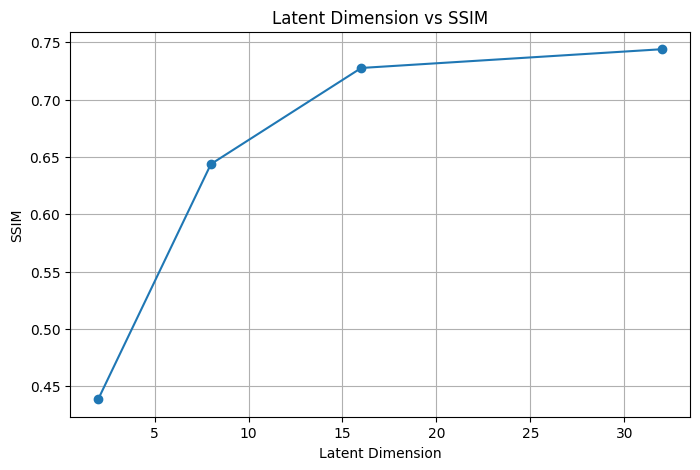

In [101]:
# ============================================================
# LATENT DIMENSION VS SSIM
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    latent_results["Latent Dimension"],
    latent_results["SSIM"],
    marker="o"
)

plt.xlabel("Latent Dimension")
plt.ylabel("SSIM")
plt.title("Latent Dimension vs SSIM")

plt.grid(True)

plt.savefig(
    RESULTS_DIR / "Latent_Dimension_vs_SSIM.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [102]:
# ============================================================
# SAVE RESULTS
# ============================================================

results.to_csv(
    "experiment7_model_results.csv",
    index=False
)

gaussian_results.to_csv(
    "experiment7_gaussian_noise_results.csv",
    index=False
)

sp_results.to_csv(
    "experiment7_salt_pepper_results.csv",
    index=False
)

latent_results.to_csv(
    "experiment7_latent_dimension_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [103]:
import shutil
from google.colab import files

# Create ZIP file
shutil.make_archive(
    "Experiment_7_Results",
    "zip",
    "Experiment_7_Results"
)

# Download ZIP
files.download("Experiment_7_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>